In [1]:
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from tools import RetrieverTools  # tools wrapper
from IPython.display import Image, display
from typing import Literal

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**LangGraph State Schema: to track overall information of the application**

In [2]:
class AgentState(MessagesState):
    query: str

***Instantiate Tools***

In [3]:
retriever = RetrieverTools()

@tool
def lexical_search(query: str) -> list:
    """BM25 keyword search with CrossEncoder reranking. Use for exact keyword matches."""
    results = retriever.lexical_search(query)
    return [str(r['document'].page_content) for r in results]

@tool
def dense_search(query: str) -> list:
    """Dense vector search with LLM compression and reranking. Use for semantic search."""
    results = retriever.dense_search(query)
    return [str(r['page_content']) for r in results]

@tool
def graph_search(query: str) -> list:
    """Graph traversal retrieval using metadata relationships. Use for related roles and departments."""
    results = retriever.graph_search(query)
    return [str(doc.page_content) for doc in results]  # serialize to strings

tools = [lexical_search, dense_search, graph_search]
tools_by_name = {tool.name: tool for tool in tools}

Initializing RetrieverTools...
Loaded 1000 documents from '/mnt/c/Users/emman/chicago_employee_data/clean_data/employee_data.csv' 


Setting up BM25 index...
Extracting docs from documents...

Tokenizing corpus for BM25...



Building BM25 index:   0%|          | 0/1000 [00:00<?, ?it/s]

BM25 index ready with 1000 documents... 


Setting up Graph Retriever...
In-memory store created with 1000 enriched documents

All retrievers ready!


***Initialize the LLM, enforcing tool use***

In [4]:
llm = ChatOllama(model="qwen3-coder-next:cloud")
llm_with_tools = llm.bind_tools(tools, tool_choice='any')

***System message components***

In [5]:
persona = "You are an expert HR data analyst specializing in municipal employee records and organizational structures.\n"

instruction = "Answer questions about Chicago city employee data by ALWAYS using ALL THREE retrieval tools before giving a final answer.\n"

context = (
    "You have access to three retrieval tools and must call all three for every query:\n"
    "1. lexical_search: for exact keyword matches on names, job titles, and departments.\n"
    "2. dense_search: for contextual compression using LLM extraction, for the semantic understanding of the query.\n"
    "3. graph_search: for finding related roles, departments, and organizational relationships.\n"
    "Do NOT stop after one tool. Always call all three tools and combine their results.\n"
)

data_format = (
    "After calling all three tools, combine and deduplicate the results by employee name. "
    "Present your final answer clearly with employee name, job title, department, full time or part time, and salary. "
    "Only include employees that appear in the tool results. Do NOT invent or assume any employee data. "
    "Exclude employees whose department does not match the query. "
    "Do not give a final answer until all three tools have been called.\n"
)

audience = "The responses are designed for analysts and administrators who need quick, accurate insights from Chicago city employee records.\n"

tone = "The tone should be professional, concise, and data-driven.\n"

sys_msg = SystemMessage(content=persona + instruction + context + data_format + audience + tone)

***LLM Node with System Prompt***

In [6]:
def llm_assistant(state: AgentState):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [sys_msg] + state["messages"]
            )
        ]
    }

***Tool handler node***

* After the LLM makes a decision, we need to execute the ```chosen tool```.

* The ```tool_handler``` node executes the tool by iterating through tool calls, get the actual ```tool name``` and run the tool to get an ```observation```.

In [7]:
def tool_handler(state: AgentState):
    """Performs the tool call."""
    
    # List for tool messages
    result = []
    
    # Iterate through tool calls, get tool, observe and create a tool message
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # Add it to our messages
    return {"messages": result}

***Conditional Routing***

Our agent needs to decide when to ```continue using tools and when to stop```. This ```conditional routing``` function directs the agent to either ```continue or terminate```.

In [8]:
def should_continue(state: AgentState) -> Literal["tool_handler", "__end__"]:
    messages = state["messages"]
    last_message = messages[-1]
    
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls:
            if tool_call["name"] == "Done":
                return END
        return "tool_handler"
    
    return END  # return END when no tool calls instead of None

***Build Workflow graph, Add Nodes, Edges, and Memory***

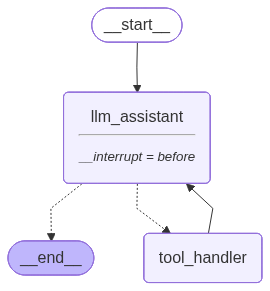

In [9]:
# Build workflow
graph_workflow = StateGraph(AgentState)

# Add nodes
graph_workflow.add_node("llm_assistant", llm_assistant)
graph_workflow.add_node("tool_handler", tool_handler)

# Add edges
graph_workflow.add_edge(START, "llm_assistant")
graph_workflow.add_conditional_edges(
    "llm_assistant",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
graph_workflow.add_edge("tool_handler", "llm_assistant")

# Memory
memory = MemorySaver()
graph = graph_workflow.compile(interrupt_before=["llm_assistant"], checkpointer=memory)

# Show Graph
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

***Run Query***

* We can see the graph is interrupted before the chat model responds.

In [10]:
query_1 = input("\nEnter query here: ")

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"messages": [HumanMessage(content=query_1)]}, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()


Enter query here:  List some firefighters


================================ Human Message =================================

List some firefighters


In [11]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='List some firefighters', additional_kwargs={}, response_metadata={}, id='076e5276-b4f0-4136-b0ae-2a460a800a4d')]}, next=('llm_assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c568-5dcf-665f-8000-a9754f97c43b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-30T16:35:54.985610+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c568-5db3-6992-bfff-aa4dbf38ef2d'}}, tasks=(PregelTask(id='4b63c7be-0551-4b98-1ce4-07b00b55e4d8', name='llm_assistant', path=('__pregel_pull', 'llm_assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

***Now, we can directly apply a state update***

Remember, updates to the messages key will use the ```add_messages``` reducer:
* If we want to over-write the existing message, we can supply the message id.
* If we simply want to append to our list of messages, then we can pass a message without an id specified.

In [12]:
query_2 = input("\nEnter query here: ")

graph.update_state(
    thread,
    {"messages": [HumanMessage(content=query_2)]},
)


Enter query here:  Actually, list some investigators


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f12c56a-0c21-6cbe-8001-ffbee0856133'}}

***Let's have a look***

* We called ```update_state``` with a new message.

* The ```add_messages reducer``` appends it to our state key -- messages.

In [13]:
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

List some firefighters
================================ Human Message =================================

Actually, list some investigators


* Now, let's proceed with our ```agent```, simply by passing ```None``` and allowing it proceed from the ```current state```.

* We emit the ```current``` and then proceed to execute the ```remaining nodes```.

In [14]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Actually, list some investigators
================================== Ai Message ==================================
Tool Calls:
  lexical_search (8c3df5b3-12fe-4902-b71a-3abe5dcdf14a)
 Call ID: 8c3df5b3-12fe-4902-b71a-3abe5dcdf14a
  Args:
    query: investigator
  dense_search (eb4232a4-ba3b-4f67-98a3-c57b1e336f01)
 Call ID: eb4232a4-ba3b-4f67-98a3-c57b1e336f01
  Args:
    query: fire investigators or criminal investigators or police investigators
  graph_search (751615f6-8536-43f3-a370-ab7b3908d7a2)
 Call ID: 751615f6-8536-43f3-a370-ab7b3908d7a2
  Args:
    query: investigator roles in public safety departments

[Lexical Search] Query: 'investigator'
Searching for: 'investigator'

Step 1: BM25 retrieval (getting 5 candidates)

Top-3 BM25 results (before reranking):


1. BM25 Score: 5.105
   name: ALVAREZ, ALFREDO
job_titles: PARKING INVESTIGATOR
department: DEPARTMENT OF FINANCE
full_or_part_time: F
salar

Now, we're back at the ```assistant```, which has our ```breakpoint```.

We can again pass ```None``` to proceed.

In [15]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================

['name: ALEXANDER, ROSS J\njob_titles: POLICE OFFICER (ASSIGNED AS EVIDENCE TECHNICIAN)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 128964.0\ntypical_hours: 36.40625\nhourly_rate: 44.2503125', 'name: ANDREWS, JENNY D\njob_titles: POLICE OFFICER (ASSIGNED AS DETECTIVE)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 127230.0\ntypical_hours: 36.40625\nhourly_rate: 44.2503125', 'name: ALEJANDRE, RODRIGO\njob_titles: INVESTIGATOR\ndepartment: OFFICE OF PUBLIC SAFETY ADMINISTRATION\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 70752.0\ntypical_hours: 36.40625\nhourly_rate: 44.2503125', 'name: ALVAREZ, JOSE M\njob_titles: POLICE OFFICER (ASSIGNED AS EVIDENCE TECHNICIAN)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 137568.0\n